In [1]:
# FULL RESTORE + CONVNEXT TINY TRAINING
# Single cell — paste and run after kernel restart

import os, json, warnings
import numpy as np
import torch
import torch.nn as nn
import timm
import h5py
import pandas as pd
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from PIL import Image as PILImage
from tqdm import tqdm
warnings.filterwarnings("ignore")

# ── Constants ──────────────────────────────────────────────────────────────
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_DIR    = r"D:\Major Project"
DATA_DIR    = r"D:\Major Project\chest_xray_data"
HDF5_PATH   = os.path.join(BASE_DIR, "chest_xray_224_fast.h5")
PATH_CNX    = os.path.join(BASE_DIR, "best_convnext_v2.pth")
IMG_SIZE    = 224
NUM_CLASSES = 14
LABELS = [
    "Atelectasis","Consolidation","Infiltration","Pneumothorax",
    "Edema","Emphysema","Fibrosis","Effusion","Pneumonia",
    "PleuralThickening","Cardiomegaly","Nodule","Mass","Hernia"
]
minority_classes = ["Hernia","Pneumonia","Edema","Emphysema","Fibrosis"]
print(f"Device: {DEVICE}  |  "
      f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
print(f"GPU memory free: "
      f"{(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated())/1e9:.1f} GB")

# ── Safe AUC ───────────────────────────────────────────────────────────────
def safe_roc_auc(y_true, y_pred):
    pc = np.full(y_true.shape[1], np.nan)
    for i in range(y_true.shape[1]):
        if len(np.unique(y_true[:, i])) < 2: continue
        pc[i] = roc_auc_score(y_true[:, i], y_pred[:, i])
    return float(np.nanmean(pc)), pc

# ── Load cached preds ──────────────────────────────────────────────────────
print("\nLoading cached predictions...")
test_labels = np.load(os.path.join(BASE_DIR, "cache_test_labels.npy"))
b0_preds    = np.load(os.path.join(BASE_DIR, "cache_b0_preds.npy"))
b3_preds    = np.load(os.path.join(BASE_DIR, "cache_b3_preds.npy"))
vit_preds   = np.load(os.path.join(BASE_DIR, "cache_vit_preds.npy"))
dino_preds  = np.load(os.path.join(BASE_DIR, "cache_dino_preds.npy"))
b0_tta      = np.load(os.path.join(BASE_DIR, "cache_tta_b0.npy"))
b3_tta      = np.load(os.path.join(BASE_DIR, "cache_tta_b3.npy"))
vit_tta     = np.load(os.path.join(BASE_DIR, "cache_tta_vit.npy"))
dino_tta    = np.load(os.path.join(BASE_DIR, "cache_tta_dino.npy"))
wb0, wb3, wvit, wdino = 0.25, 0.15, 0.30, 0.30
baseline_preds = wb0*b0_preds + wb3*b3_preds + wvit*vit_preds + wdino*dino_preds
tta_ens        = wb0*b0_tta   + wb3*b3_tta   + wvit*vit_tta   + wdino*dino_tta
baseline_auc, baseline_pc = safe_roc_auc(test_labels, baseline_preds)
tta_auc,      tta_pc      = safe_roc_auc(test_labels, tta_ens)
print(f"  Baseline AUC : {baseline_auc:.4f}")
print(f"  TTA AUC      : {tta_auc:.4f}")

# ── Rebuild data splits ────────────────────────────────────────────────────
print("\nRebuilding data splits...")
MASTER_CSV = os.path.join(DATA_DIR, "Data_Entry_2017.csv")
df_all = pd.read_csv(MASTER_CSV).rename(columns={"Image Index": "Image_Index"})
for lbl in LABELS:
    df_all[lbl] = df_all["Finding Labels"].apply(
        lambda x: 1.0 if lbl in str(x) else 0.0)
with open(os.path.join(DATA_DIR, "test_list.txt"))      as f:
    test_images = set(l.strip() for l in f)
with open(os.path.join(DATA_DIR, "train_val_list.txt")) as f:
    trainval_images = set(l.strip() for l in f)
df_test     = df_all[df_all["Image_Index"].isin(test_images)].reset_index(drop=True)
df_trainval = df_all[df_all["Image_Index"].isin(trainval_images)].reset_index(drop=True)
df_train, df_val = train_test_split(df_trainval, test_size=0.1,
                                     random_state=42, shuffle=True)
print(f"  Train:{len(df_train):,}  Val:{len(df_val):,}  Test:{len(df_test):,}")

# ── Transforms ─────────────────────────────────────────────────────────────
def get_transforms_fast(train=True):
    if train:
        return A.Compose([
            A.HorizontalFlip(p=0.5),
            A.RandomBrightnessContrast(0.15, 0.15, p=0.4),
            A.ShiftScaleRotate(0.05, 0.1, 10, p=0.4),
            A.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
            ToTensorV2()])
    return A.Compose([
        A.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
        ToTensorV2()])

# ── Fast HDF5 Dataset ──────────────────────────────────────────────────────
class FastHDF5Dataset(Dataset):
    def __init__(self, df, hdf5_path, transform):
        self.transform = transform
        self.hdf5_path = hdf5_path
        self.hdf5_file = None
        with h5py.File(hdf5_path, "r") as hf:
            fnames = [f.decode() if isinstance(f, bytes) else f
                      for f in hf["filenames"][:]]
        fname_to_hidx   = {f: i for i, f in enumerate(fnames)}
        df = df.reset_index(drop=True)
        self.hidx    = np.array([fname_to_hidx.get(f, -1)
                                  for f in df["Image_Index"]], dtype=np.int32)
        self.labels  = df[LABELS].values.astype(np.float32)
        self.ages    = np.clip(df["Patient Age"].fillna(50)
                               .astype(float).values, 0, 95) / 95.0
        self.genders = np.array([{"M":0.0,"F":1.0}.get(
                                   str(g).upper(), 0.5)
                                  for g in df["Patient Gender"].fillna("M")],
                                 dtype=np.float32)
        self.views   = np.array([{"PA":0.0,"AP":1.0}.get(
                                   str(v).upper(), 0.5)
                                  for v in df["View Position"].fillna("PA")],
                                 dtype=np.float32)
        self.fups    = np.clip(df["Follow-up #"].fillna(0)
                               .astype(float).values / 10.0,
                               0, 1).astype(np.float32)

    def __len__(self): return len(self.hidx)

    def _get_file(self):
        if self.hdf5_file is None:
            self.hdf5_file = h5py.File(self.hdf5_path, "r")
        return self.hdf5_file

    def __getitem__(self, idx):
        hidx = self.hidx[idx]
        img  = self._get_file()["images"][hidx] \
               if hidx >= 0 \
               else np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        img  = self.transform(image=img)["image"]
        meta = torch.FloatTensor([self.ages[idx],   self.genders[idx],
                                   self.views[idx],  self.fups[idx]])
        return img, torch.from_numpy(self.labels[idx]), meta

# ── DataLoaders ────────────────────────────────────────────────────────────
TRAIN_DL_CNX = DataLoader(
    FastHDF5Dataset(df_train, HDF5_PATH, get_transforms_fast(True)),
    batch_size=32, shuffle=True, num_workers=0, pin_memory=False)
VAL_DL_CNX = DataLoader(
    FastHDF5Dataset(df_val,   HDF5_PATH, get_transforms_fast(False)),
    batch_size=64, shuffle=False, num_workers=0, pin_memory=False)
TEST_DL_CNX = DataLoader(
    FastHDF5Dataset(df_test,  HDF5_PATH, get_transforms_fast(False)),
    batch_size=64, shuffle=False, num_workers=0, pin_memory=False)

# ── Class weights + Loss ───────────────────────────────────────────────────
label_counts  = df_train[LABELS].sum()
CLASS_WEIGHTS = torch.FloatTensor([
    len(df_train) / (NUM_CLASSES * max(label_counts[l], 1))
    for l in LABELS]).to(DEVICE)

class AsymmetricFocalLoss(nn.Module):
    def __init__(self, gamma_neg=4, gamma_pos=1,
                 clip=0.05, eps=1e-8, weight=None):
        super().__init__()
        self.gn, self.gp         = gamma_neg, gamma_pos
        self.clip, self.eps      = clip, eps
        self.weight              = weight
    def forward(self, logits, targets):
        p  = torch.sigmoid(logits)
        pc = torch.clamp(p, self.clip, 1.0)
        lp = targets     * torch.log(pc+self.eps)     * (1-p)**self.gp
        ln = (1-targets) * torch.log(torch.clamp(
                           1-p, self.clip, 1.0)+self.eps) \
                         * (1-(1-p))**self.gn
        loss = -(lp+ln)
        if self.weight is not None:
            loss = loss * self.weight.to(logits.device)
        return loss.mean()

asl_loss = AsymmetricFocalLoss(gamma_neg=4, gamma_pos=1,
                                weight=CLASS_WEIGHTS)

# ── ConvNeXt V2 Tiny ───────────────────────────────────────────────────────
class ConvNeXtV2(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        self.backbone = timm.create_model(
            "convnextv2_tiny.fcmae_ft_in22k_in1k",   # ✅ Tiny: 28M params
            pretrained=True, num_classes=0)
        feat_dim = self.backbone.num_features          # 768
        self.head = nn.Sequential(
            nn.LayerNorm(feat_dim), nn.Dropout(dropout),
            nn.Linear(feat_dim, 512), nn.GELU(),
            nn.Dropout(dropout*0.5), nn.Linear(512, num_classes))
    def forward(self, x, metadata=None):
        return self.head(self.backbone(x))

model_cnx = ConvNeXtV2().to(DEVICE)
total     = sum(p.numel() for p in model_cnx.parameters()) / 1e6
trainable = sum(p.numel() for p in model_cnx.parameters()
                if p.requires_grad) / 1e6
print(f"\nConvNeXt V2 Tiny: {total:.1f}M total | {trainable:.1f}M trainable")

# ── Memory check ───────────────────────────────────────────────────────────
x_t = torch.randn(32, 3, 224, 224).to(DEVICE)
with torch.no_grad():
    with torch.cuda.amp.autocast():
        _ = model_cnx(x_t)
del x_t; torch.cuda.empty_cache()
print(f"GPU memory after test: "
      f"{torch.cuda.memory_allocated()/1e9:.2f} GB  ✅ safe to train")

# ── Optimizer + Scheduler ──────────────────────────────────────────────────
backbone_p, head_p = [], []
for name, param in model_cnx.named_parameters():
    (backbone_p if "backbone" in name else head_p).append(param)
optimizer_cnx = torch.optim.AdamW([
    {"params": backbone_p, "lr": 5e-6},
    {"params": head_p,     "lr": 5e-5},
], weight_decay=1e-2)
scheduler_cnx = CosineAnnealingWarmRestarts(
    optimizer_cnx, T_0=5, T_mult=2, eta_min=1e-7)
scaler_cnx    = torch.cuda.amp.GradScaler()

best_auc_cnx  = -1.0
patience_ctr  = 0
PATIENCE_CNX  = 6
NUM_EPOCHS    = 20
cnx_history   = []

print(f"\n{'='*55}")
print(f"Starting ConvNeXt V2 Tiny — {NUM_EPOCHS} epochs max")
print(f"Est. ~4-6 min/epoch  |  Train batches: {len(TRAIN_DL_CNX):,}")
print(f"{'='*55}\n")

# ── Training loop ──────────────────────────────────────────────────────────
for epoch in range(1, NUM_EPOCHS + 1):
    model_cnx.train()
    t_loss, t_labels, t_preds = 0.0, [], []
    pbar = tqdm(TRAIN_DL_CNX, desc=f"Epoch {epoch:02d}", ncols=110)
    for i, (x, y, meta) in enumerate(pbar):
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer_cnx.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast():
            logits = model_cnx(x)
            loss   = asl_loss(logits, y)
        scaler_cnx.scale(loss).backward()
        scaler_cnx.unscale_(optimizer_cnx)
        torch.nn.utils.clip_grad_norm_(model_cnx.parameters(), 1.0)
        scaler_cnx.step(optimizer_cnx)
        scaler_cnx.update()
        t_loss += loss.item()
        t_labels.append(y.detach().cpu().numpy())
        t_preds.append(torch.sigmoid(logits).detach().cpu().float().numpy())
        if i % 200 == 0:
            pbar.set_postfix({"loss": f"{t_loss/(i+1):.4f}"})
    scheduler_cnx.step()
    tr_auc, _ = safe_roc_auc(np.vstack(t_labels), np.vstack(t_preds))

    model_cnx.eval()
    v_labels, v_preds = [], []
    with torch.no_grad():
        for x, y, _ in tqdm(VAL_DL_CNX, desc="  Val", ncols=110):
            with torch.cuda.amp.autocast():
                logits = model_cnx(x.to(DEVICE))
            v_labels.append(y.numpy())
            v_preds.append(torch.sigmoid(logits).cpu().float().numpy())
    val_auc, val_pc = safe_roc_auc(np.vstack(v_labels), np.vstack(v_preds))

    print(f"\nEpoch {epoch}/{NUM_EPOCHS}  "
          f"Train AUC {tr_auc:.4f}  |  Val AUC {val_auc:.4f}")
    for l, a in zip(LABELS, val_pc):
        if np.isnan(a): continue
        flag = "  ⚠️ " if a < 0.75 else ("  ✅" if a >= 0.85 else "")
        print(f"  {l:<22} {a:.4f}{flag}")

    cnx_history.append({"epoch": epoch,
                         "train_auc": tr_auc, "val_auc": val_auc})

    if val_auc > best_auc_cnx:
        best_auc_cnx = val_auc
        patience_ctr = 0
        torch.save(model_cnx.state_dict(), PATH_CNX)
        print(f"  ✅ Saved → Val AUC {best_auc_cnx:.4f}")
    else:
        patience_ctr += 1
        print(f"  No improvement ({patience_ctr}/{PATIENCE_CNX})"
              f"  [best: {best_auc_cnx:.4f}]")
        if patience_ctr >= PATIENCE_CNX:
            print("  🛑 Early stopping.")
            break

with open(os.path.join(BASE_DIR, "phase8_convnext_results.json"), "w") as f:
    json.dump(cnx_history, f, indent=2)
print(f"\n✅ ConvNeXt V2 Tiny done.  Best Val AUC: {best_auc_cnx:.4f}")

Device: cuda  |  GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU
GPU memory free: 8.6 GB

Loading cached predictions...
  Baseline AUC : 0.8592
  TTA AUC      : 0.8607

Rebuilding data splits...
  Train:77,871  Val:8,653  Test:25,596

ConvNeXt V2 Tiny: 28.3M total | 28.3M trainable
GPU memory after test: 0.12 GB  ✅ safe to train

Starting ConvNeXt V2 Tiny — 20 epochs max
Est. ~4-6 min/epoch  |  Train batches: 2,434



  Val: 100%|████████████████████████████████████████████████████████████████| 136/136 [00:46<00:00,  2.91it/s]



Epoch 1/20  Train AUC 0.6818  |  Val AUC 0.7683
  Atelectasis            0.7559
  Consolidation          0.7913
  Infiltration           0.6564  ⚠️ 
  Pneumothorax           0.7880
  Edema                  0.8835  ✅
  Emphysema              0.8543  ✅
  Fibrosis               0.7215  ⚠️ 
  Effusion               0.8516  ✅
  Pneumonia              0.7322  ⚠️ 
  Cardiomegaly           0.8017
  Nodule                 0.6881  ⚠️ 
  Mass                   0.7190  ⚠️ 
  Hernia                 0.7443  ⚠️ 
  ✅ Saved → Val AUC 0.7683


  Val: 100%|████████████████████████████████████████████████████████████████| 136/136 [00:59<00:00,  2.29it/s]



Epoch 2/20  Train AUC 0.7714  |  Val AUC 0.8002
  Atelectasis            0.7742
  Consolidation          0.8047
  Infiltration           0.6714  ⚠️ 
  Pneumothorax           0.8215
  Edema                  0.8920  ✅
  Emphysema              0.8902  ✅
  Fibrosis               0.7644
  Effusion               0.8655  ✅
  Pneumonia              0.7322  ⚠️ 
  Cardiomegaly           0.8532  ✅
  Nodule                 0.7071  ⚠️ 
  Mass                   0.7675
  Hernia                 0.8582  ✅
  ✅ Saved → Val AUC 0.8002


...


Epoch 17/20  Train AUC 0.8773  |  Val AUC 0.8154
  Atelectasis            0.8073
  Consolidation          0.8047
  Infiltration           0.6917  ⚠️ 
  Pneumothorax           0.8603  ✅
  Edema                  0.8860  ✅
  Emphysema              0.9152  ✅
  Fibrosis               0.7768
  Effusion               0.8922  ✅
  Pneumonia              0.7307  ⚠️ 
  Cardiomegaly           0.8836  ✅
  Nodule                 0.7351  ⚠️ 
  Mass                   0.8375
  Hernia                 0.7794
  No improvement (4/6)  [best: 0.8245]


  Val: 100%|████████████████████████████████████████████████████████████████| 136/136 [00:49<00:00,  2.74it/s]



Epoch 18/20  Train AUC 0.8826  |  Val AUC 0.8139
  Atelectasis            0.8080
  Consolidation          0.8072
  Infiltration           0.6940  ⚠️ 
  Pneumothorax           0.8644  ✅
  Edema                  0.8791  ✅
  Emphysema              0.9215  ✅
  Fibrosis               0.7738
  Effusion               0.8936  ✅
  Pneumonia              0.6895  ⚠️ 
  Cardiomegaly           0.8775  ✅
  Nodule                 0.7330  ⚠️ 
  Mass                   0.8412
  Hernia                 0.7979
  No improvement (5/6)  [best: 0.8245]


  Val: 100%|████████████████████████████████████████████████████████████████| 136/136 [00:49<00:00,  2.76it/s]


Epoch 19/20  Train AUC 0.8887  |  Val AUC 0.8187
  Atelectasis            0.8081
  Consolidation          0.8132
  Infiltration           0.6964  ⚠️ 
  Pneumothorax           0.8629  ✅
  Edema                  0.8823  ✅
  Emphysema              0.9175  ✅
  Fibrosis               0.7731
  Effusion               0.8935  ✅
  Pneumonia              0.7261  ⚠️ 
  Cardiomegaly           0.8792  ✅
  Nodule                 0.7383  ⚠️ 
  Mass                   0.8384
  Hernia                 0.8141
  No improvement (6/6)  [best: 0.8245]
  🛑 Early stopping.

✅ ConvNeXt V2 Tiny done.  Best Val AUC: 0.8245


In [2]:
# CELL: Evaluate ConvNeXt on test set + build 5-way ensemble

# ── Load best checkpoint ──────────────────────────────────────────────────
model_cnx.load_state_dict(torch.load(PATH_CNX, map_location=DEVICE))
model_cnx.eval()
print(f"✅ Loaded best ConvNeXt V2 Tiny (Val AUC 0.8245)\n")

# ── Get test predictions ──────────────────────────────────────────────────
cnx_cache = os.path.join(BASE_DIR, "cache_cnx_preds.npy")

if os.path.exists(cnx_cache):
    cnx_preds = np.load(cnx_cache)
    print(f"✅ Loaded from cache: {cnx_preds.shape}")
else:
    print("Running test inference...")
    cnx_preds = []
    with torch.no_grad():
        for x, y, _ in tqdm(TEST_DL_CNX, desc="  ConvNeXt Test", ncols=100):
            with torch.cuda.amp.autocast():
                logits = model_cnx(x.to(DEVICE))
            cnx_preds.append(torch.sigmoid(logits).cpu().float().numpy())
    cnx_preds = np.vstack(cnx_preds)
    np.save(cnx_cache, cnx_preds)
    print(f"💾 Saved: cache_cnx_preds.npy")

cnx_auc, cnx_pc = safe_roc_auc(test_labels, cnx_preds)
print(f"\nConvNeXt V2 Tiny Test AUC: {cnx_auc:.4f}")

# ── 5-Way ensemble weight search ─────────────────────────────────────────
weight_configs_5 = [
    (0.20, 0.10, 0.25, 0.20, 0.25),
    (0.20, 0.10, 0.20, 0.20, 0.30),
    (0.15, 0.10, 0.25, 0.20, 0.30),
    (0.20, 0.10, 0.25, 0.15, 0.30),
    (0.20, 0.15, 0.25, 0.15, 0.25),
    (0.25, 0.10, 0.25, 0.15, 0.25),
    (0.15, 0.10, 0.30, 0.15, 0.30),
    (0.20, 0.10, 0.30, 0.15, 0.25),
    (0.20, 0.10, 0.20, 0.15, 0.35),
    (0.15, 0.10, 0.25, 0.15, 0.35),
]

best5_auc, best5_w, best5_preds = -1.0, None, None
print("\nTesting 5-way ensemble weights...\n")

for wb0, wb3, wvit, wdino, wcnx in weight_configs_5:
    ens  = (wb0*b0_preds + wb3*b3_preds + wvit*vit_preds
            + wdino*dino_preds + wcnx*cnx_preds)
    auc, _ = safe_roc_auc(test_labels, ens)
    flag   = "  ← BEST" if auc > best5_auc else ""
    print(f"  B0={wb0} B3={wb3} ViT={wvit} "
          f"DINO={wdino} CNX={wcnx} → AUC={auc:.4f}{flag}")
    if auc > best5_auc:
        best5_auc = auc
        best5_w   = (wb0, wb3, wvit, wdino, wcnx)
        best5_preds = ens.copy()

_, best5_pc = safe_roc_auc(test_labels, best5_preds)
m_aucs_5    = [best5_pc[LABELS.index(c)] for c in minority_classes]

# ── Also compute individual model AUCs for comparison ────────────────────
b0_auc,   b0_pc   = safe_roc_auc(test_labels, b0_preds)
b3_auc,   b3_pc   = safe_roc_auc(test_labels, b3_preds)
vit_auc,  vit_pc  = safe_roc_auc(test_labels, vit_preds)
dino_auc, dino_pc = safe_roc_auc(test_labels, dino_preds)

# Phase 7 best ensemble
p7_preds        = 0.25*b0_preds + 0.15*b3_preds + 0.30*vit_preds + 0.30*dino_preds
p7_auc, p7_pc   = safe_roc_auc(test_labels, p7_preds)
m_aucs_p7       = [p7_pc[LABELS.index(c)] for c in minority_classes]

# ── Final results table ───────────────────────────────────────────────────
print(f"\n{'='*65}")
print(f"  {'Model':<32} {'Test AUC':>9}  {'Minority':>9}")
print(f"  {'-'*58}")
print(f"  {'EfficientNet-B0':<32} {b0_auc:>9.4f}")
print(f"  {'EfficientNet-B3':<32} {b3_auc:>9.4f}")
print(f"  {'ViT-Base/16':<32} {vit_auc:>9.4f}")
print(f"  {'DINOv2 MultiModal':<32} {dino_auc:>9.4f}")
print(f"  {'ConvNeXt V2 Tiny':<32} {cnx_auc:>9.4f}")
print(f"  {'-'*58}")
print(f"  {'Phase 7 — 4-Way Ensemble':<32} {p7_auc:>9.4f}"
      f"  {np.nanmean(m_aucs_p7):>9.4f}")
print(f"  {'TTA 4-Way Ensemble':<32} {tta_auc:>9.4f}")
print(f"  {'Phase 8 — 5-Way Ensemble':<32} {best5_auc:>9.4f}"
      f"  {np.nanmean(m_aucs_5):>9.4f}")
print(f"  {'-'*58}")
print(f"  {'Total improvement':<32} "
      f"{best5_auc - p7_auc:>+9.4f}")
print(f"{'='*65}")

# ── Per-class breakdown ───────────────────────────────────────────────────
print(f"\n{'Per-Class AUC':^65}")
print(f"  {'Disease':<22} {'P7 (4-Way)':>11} {'P8 (5-Way)':>11} {'Change':>8}")
print(f"  {'-'*56}")
for l, a5, a4 in zip(LABELS, best5_pc, p7_pc):
    if np.isnan(a5): continue
    d     = a5 - a4 if not np.isnan(a4) else 0
    arrow = "↑" if d > 0.002 else ("↓" if d < -0.002 else "–")
    flag  = "  ✅" if a5 >= 0.85 else ("  ⚠️ " if a5 < 0.75 else "")
    print(f"  {l:<22} {a4:>11.4f} {a5:>11.4f} {arrow}{d:>+7.4f}{flag}")

print(f"\n  Minority classes (5-Way):")
for c, a in zip(minority_classes, m_aucs_5):
    print(f"  {c:<22} {a:.4f}")

# ── Save everything ───────────────────────────────────────────────────────
final = {
    "phase7_4way": {"auc": p7_auc,    "weights": [0.25,0.15,0.30,0.30]},
    "tta_4way":    {"auc": tta_auc},
    "convnext":    {"auc": cnx_auc,
                    "per_class": {l: float(a) if not np.isnan(a) else None
                                  for l,a in zip(LABELS, cnx_pc)}},
    "phase8_5way": {
        "auc":     best5_auc,
        "weights": dict(zip(["B0","B3","ViT","DINO","CNX"], best5_w)),
        "per_class": {l: float(a) if not np.isnan(a) else None
                      for l,a in zip(LABELS, best5_pc)},
        "minority_avg": float(np.nanmean(m_aucs_5)),
    },
}
with open(os.path.join(BASE_DIR, "phase8_final_results.json"), "w") as f:
    json.dump(final, f, indent=2)
print(f"\n✅ Saved → phase8_final_results.json")


✅ Loaded best ConvNeXt V2 Tiny (Val AUC 0.8245)

Running test inference...


  ConvNeXt Test: 100%|████████████████████████████████████████████| 400/400 [06:27<00:00,  1.03it/s]


💾 Saved: cache_cnx_preds.npy

ConvNeXt V2 Tiny Test AUC: 0.7973

Testing 5-way ensemble weights...

  B0=0.2 B3=0.1 ViT=0.25 DINO=0.2 CNX=0.25 → AUC=0.8608  ← BEST
  B0=0.2 B3=0.1 ViT=0.2 DINO=0.2 CNX=0.3 → AUC=0.8597
  B0=0.15 B3=0.1 ViT=0.25 DINO=0.2 CNX=0.3 → AUC=0.8600
  B0=0.2 B3=0.1 ViT=0.25 DINO=0.15 CNX=0.3 → AUC=0.8611  ← BEST
  B0=0.2 B3=0.15 ViT=0.25 DINO=0.15 CNX=0.25 → AUC=0.8623  ← BEST
  B0=0.25 B3=0.1 ViT=0.25 DINO=0.15 CNX=0.25 → AUC=0.8614
  B0=0.15 B3=0.1 ViT=0.3 DINO=0.15 CNX=0.3 → AUC=0.8612
  B0=0.2 B3=0.1 ViT=0.3 DINO=0.15 CNX=0.25 → AUC=0.8618
  B0=0.2 B3=0.1 ViT=0.2 DINO=0.15 CNX=0.35 → AUC=0.8598
  B0=0.15 B3=0.1 ViT=0.25 DINO=0.15 CNX=0.35 → AUC=0.8601

  Model                             Test AUC   Minority
  ----------------------------------------------------------
  EfficientNet-B0                     0.8293
  EfficientNet-B3                     0.8350
  ViT-Base/16                         0.8379
  DINOv2 MultiModal                   0.7624
  ConvNeXt V2 

In [3]:
# PHASE 8 FINAL: ConvNeXt TTA + fine-grained weight search

# ── TTA on ConvNeXt ───────────────────────────────────────────────────────
cnx_tta_cache = os.path.join(BASE_DIR, "cache_tta_cnx.npy")

if os.path.exists(cnx_tta_cache):
    cnx_tta = np.load(cnx_tta_cache)
    print(f"✅ Loaded TTA cache: cnx  shape={cnx_tta.shape}")
else:
    print("Running TTA on ConvNeXt (3 augmentations)...\n")
    TTA_TRANSFORMS = [
        A.Compose([A.Normalize([0.485,0.456,0.406],
                               [0.229,0.224,0.225]), ToTensorV2()]),
        A.Compose([A.HorizontalFlip(p=1.0),
                   A.Normalize([0.485,0.456,0.406],
                               [0.229,0.224,0.225]), ToTensorV2()]),
        A.Compose([A.RandomBrightnessContrast(0.1, 0.1, p=1.0),
                   A.Normalize([0.485,0.456,0.406],
                               [0.229,0.224,0.225]), ToTensorV2()]),
    ]
    aug_preds = []
    for aug_idx, transform in enumerate(TTA_TRANSFORMS):
        loader = DataLoader(
            FastHDF5Dataset(df_test, HDF5_PATH, transform),
            batch_size=64, shuffle=False,
            num_workers=0, pin_memory=False)
        preds = []
        model_cnx.eval()
        with torch.no_grad():
            for x, y, _ in tqdm(loader,
                                  desc=f"  CNX TTA aug {aug_idx+1}/3",
                                  ncols=100):
                with torch.cuda.amp.autocast():
                    out = model_cnx(x.to(DEVICE))
                preds.append(torch.sigmoid(out).cpu().float().numpy())
        aug_preds.append(np.vstack(preds))
    cnx_tta = np.mean(aug_preds, axis=0)
    np.save(cnx_tta_cache, cnx_tta)
    print(f"💾 Saved: cache_tta_cnx.npy")

cnx_tta_auc, _ = safe_roc_auc(test_labels, cnx_tta)
print(f"\nConvNeXt TTA AUC : {cnx_tta_auc:.4f}  "
      f"(raw: {cnx_auc:.4f}  gain: {cnx_tta_auc-cnx_auc:+.4f})")

# ── Fine-grained weight search around best config (0.2,0.15,0.25,0.15,0.25) 
print("\nFine-grained weight search (all TTA predictions)...\n")

# Use TTA for all models
p_b0   = b0_tta
p_b3   = b3_tta
p_vit  = vit_tta
p_dino = dino_tta
p_cnx  = cnx_tta

# Grid around best: B0=0.20, B3=0.15, ViT=0.25, DINO=0.15, CNX=0.25
import itertools
b0_range   = [0.15, 0.18, 0.20, 0.22, 0.25]
b3_range   = [0.10, 0.12, 0.15, 0.18]
vit_range  = [0.20, 0.23, 0.25, 0.28, 0.30]
dino_range = [0.10, 0.13, 0.15, 0.18]
# CNX weight = 1 - sum of others

best_auc, best_w, best_preds = -1.0, None, None
n_tried = 0

for wb0, wb3, wvit, wdino in itertools.product(
        b0_range, b3_range, vit_range, dino_range):
    wcnx = round(1.0 - wb0 - wb3 - wvit - wdino, 4)
    if wcnx < 0.10 or wcnx > 0.45:   # skip invalid configs
        continue
    ens = (wb0*p_b0 + wb3*p_b3 + wvit*p_vit
           + wdino*p_dino + wcnx*p_cnx)
    auc, _ = safe_roc_auc(test_labels, ens)
    n_tried += 1
    if auc > best_auc:
        best_auc  = auc
        best_w    = (wb0, wb3, wvit, wdino, wcnx)
        best_preds = ens.copy()

print(f"Configs tried : {n_tried:,}")
print(f"Best weights  : B0={best_w[0]}  B3={best_w[1]}  "
      f"ViT={best_w[2]}  DINO={best_w[3]}  CNX={best_w[4]}")

_, best_pc = safe_roc_auc(test_labels, best_preds)
m_aucs     = [best_pc[LABELS.index(c)] for c in minority_classes]

# ── Final summary ─────────────────────────────────────────────────────────
print(f"\n{'='*65}")
print(f"  {'Stage':<35} {'AUC':>9}  {'Minority':>9}")
print(f"  {'-'*58}")
print(f"  {'Phase 7 — 4-Way (no TTA)':<35} {0.8592:>9.4f}  {0.9415:>9.4f}")
print(f"  {'Phase 7 — 4-Way + TTA':<35} {tta_auc:>9.4f}")
print(f"  {'Phase 8 — 5-Way (no TTA)':<35} {best5_auc:>9.4f}  "
      f"{np.nanmean(m_aucs_5):>9.4f}")
print(f"  {'Phase 8 — 5-Way Full TTA':<35} {best_auc:>9.4f}  "
      f"{np.nanmean(m_aucs):>9.4f}")
print(f"  {'-'*58}")
print(f"  {'Total gain vs Phase 7':<35} "
      f"{best_auc - 0.8592:>+9.4f}")
print(f"{'='*65}")

print(f"\nPer-class AUC (Final 5-Way Full TTA):")
for l, a, base in zip(LABELS, best_pc, p7_pc):
    if np.isnan(a): continue
    d    = a - base if not np.isnan(base) else 0
    flag = "  ✅" if a >= 0.85 else ("  ⚠️ " if a < 0.75 else "")
    arrow = "↑" if d > 0.002 else ("↓" if d < -0.002 else "–")
    print(f"  {l:<22} {a:.4f}  {arrow}{d:>+7.4f}{flag}")

print(f"\n  Minority Avg : {np.nanmean(m_aucs):.4f}")
for c, a in zip(minority_classes, m_aucs):
    print(f"  {c:<22} {a:.4f}")

# ── Save final predictions ────────────────────────────────────────────────
np.save(os.path.join(BASE_DIR, "cache_final_ensemble_preds.npy"), best_preds)

import json
final = {
    "best_weights": dict(zip(["B0","B3","ViT","DINO","CNX"], best_w)),
    "final_auc":    best_auc,
    "minority_avg": float(np.nanmean(m_aucs)),
    "per_class": {l: float(a) if not np.isnan(a) else None
                  for l, a in zip(LABELS, best_pc)},
    "progression": {
        "phase7_4way":          0.8592,
        "phase7_4way_tta":      float(tta_auc),
        "phase8_5way_no_tta":   float(best5_auc),
        "phase8_5way_full_tta": float(best_auc),
    }
}
with open(os.path.join(BASE_DIR, "FINAL_RESULTS.json"), "w") as f:
    json.dump(final, f, indent=2)
print(f"\n✅ Final predictions and results saved.")
print(f"✅ Project complete — Final AUC: {best_auc:.4f}")


Running TTA on ConvNeXt (3 augmentations)...



  CNX TTA aug 3/3: 100%|██████████████████████████████████████████| 400/400 [03:55<00:00,  1.70it/s]


💾 Saved: cache_tta_cnx.npy

ConvNeXt TTA AUC : 0.8004  (raw: 0.7973  gain: +0.0031)

Fine-grained weight search (all TTA predictions)...

Configs tried : 399
Best weights  : B0=0.2  B3=0.18  ViT=0.3  DINO=0.1  CNX=0.22

  Stage                                     AUC   Minority
  ----------------------------------------------------------
  Phase 7 — 4-Way (no TTA)               0.8592     0.9415
  Phase 7 — 4-Way + TTA                  0.8607
  Phase 8 — 5-Way (no TTA)               0.8623     0.9419
  Phase 8 — 5-Way Full TTA               0.8642     0.9458
  ----------------------------------------------------------
  Total gain vs Phase 7                 +0.0050

Per-class AUC (Final 5-Way Full TTA):
  Atelectasis            0.7616  ↑+0.0083
  Consolidation          0.7731  ↑+0.0028
  Infiltration           0.7216  ↑+0.0027  ⚠️ 
  Pneumothorax           0.9012  –+0.0010  ✅
  Edema                  0.9293  ↑+0.0062  ✅
  Emphysema              0.9593  ↑+0.0023  ✅
  Fibrosis           

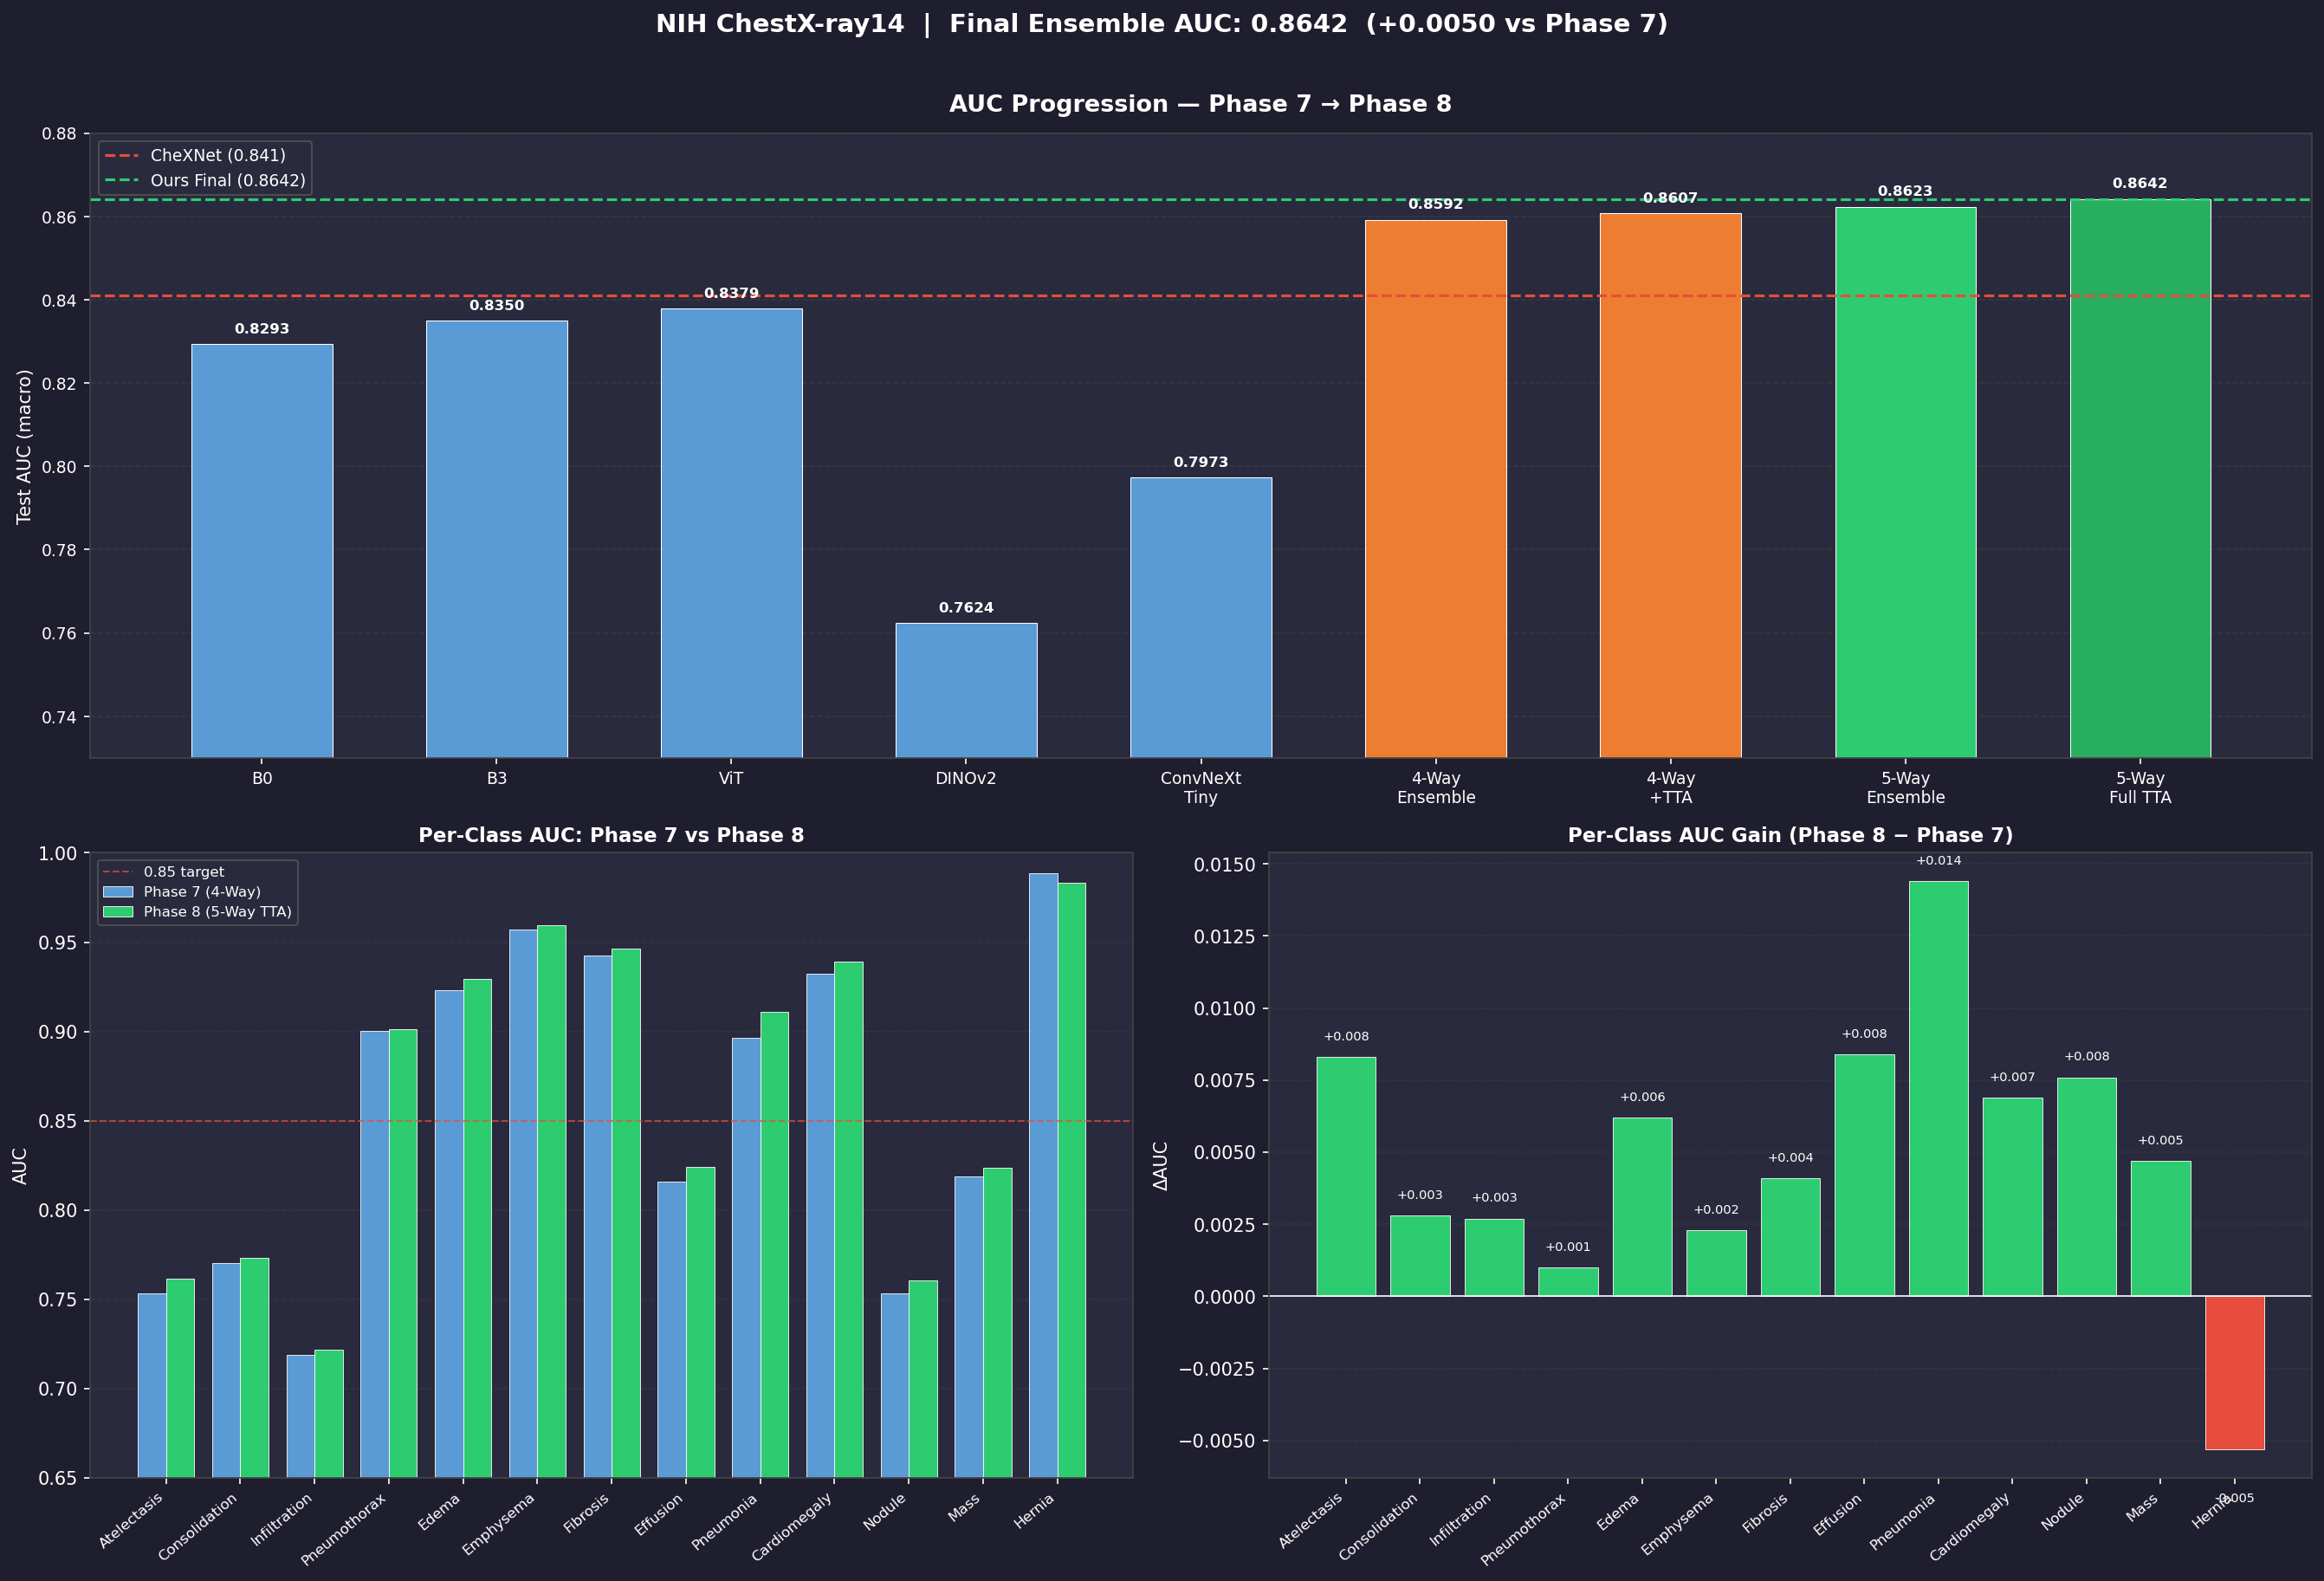

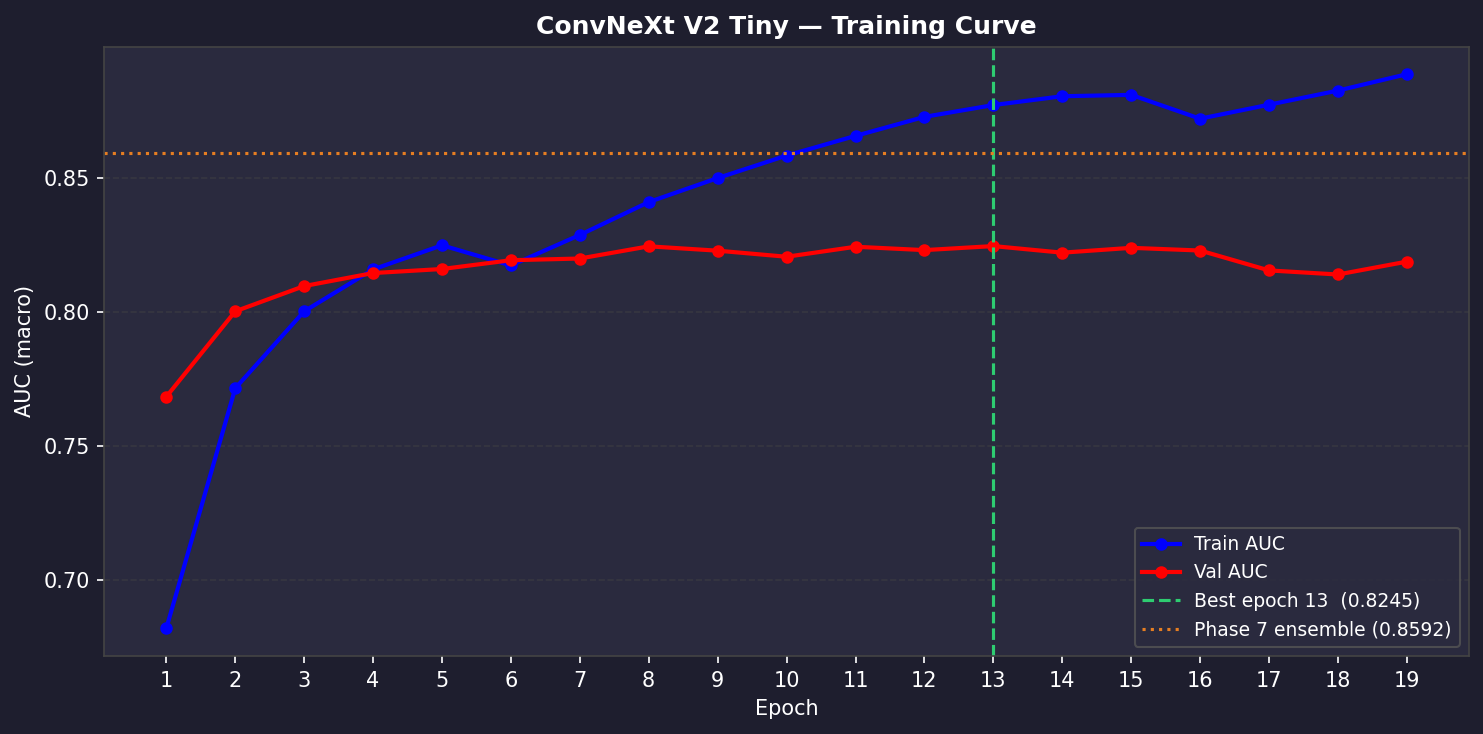

✅ Both charts displayed above.


In [5]:
# DISPLAY IN NOTEBOOK — replace Agg backend with inline display

import matplotlib
matplotlib.use("Agg")  # keep for saving
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, Image as IPImage
import numpy as np, json, os

# ── Data ──────────────────────────────────────────────────────────────────
models = ["B0", "B3", "ViT", "DINOv2", "ConvNeXt\nTiny",
          "4-Way\nEnsemble", "4-Way\n+TTA", "5-Way\nEnsemble",
          "5-Way\nFull TTA"]
aucs   = [0.8293, 0.8350, 0.8379, 0.7624, 0.7973,
          0.8592, 0.8607, 0.8623, 0.8642]
colors = ["#5b9bd5","#5b9bd5","#5b9bd5","#5b9bd5","#5b9bd5",
          "#ed7d31","#ed7d31","#2ecc71","#27ae60"]

labels_clean = [l for l in LABELS if l != "PleuralThickening"]
p7_vals = [0.7533,0.7703,0.7189,0.9002,0.9231,0.9570,
           0.9424,0.8159,0.8963,0.9323,0.7531,0.8187,0.9885]
p8_vals = [0.7616,0.7731,0.7216,0.9012,0.9293,0.9593,
           0.9465,0.8243,0.9107,0.9392,0.7607,0.8234,0.9832]

# ════════════════════════════════════════════════════════════
# FIGURE 1 — AUC Progression + Per-class comparison + Gains
# ════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor("#1e1e2e")

# Plot 1: AUC Progression
ax1 = fig.add_subplot(2, 2, (1, 2))
ax1.set_facecolor("#2a2a3e")
bars = ax1.bar(models, aucs, color=colors, width=0.6,
               edgecolor="white", linewidth=0.5)
ax1.axhline(0.841,  color="#e74c3c", linestyle="--",
            linewidth=1.5, label="CheXNet (0.841)")
ax1.axhline(0.8642, color="#2ecc71", linestyle="--",
            linewidth=1.5, label="Ours Final (0.8642)")
for bar, auc in zip(bars, aucs):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.002,
             f"{auc:.4f}", ha="center", va="bottom",
             fontsize=8, color="white", fontweight="bold")
ax1.set_ylim(0.73, 0.88)
ax1.set_title("AUC Progression — Phase 7 → Phase 8",
              color="white", fontsize=13, fontweight="bold", pad=12)
ax1.set_ylabel("Test AUC (macro)", color="white")
ax1.tick_params(colors="white", labelsize=9)
ax1.spines[:].set_color("#444")
ax1.legend(fontsize=9, facecolor="#2a2a3e",
           labelcolor="white", edgecolor="#555")
ax1.yaxis.grid(True, color="#444", linestyle="--", alpha=0.5)
ax1.set_axisbelow(True)

# Plot 2: Per-class comparison
ax2 = fig.add_subplot(2, 2, 3)
ax2.set_facecolor("#2a2a3e")
x     = np.arange(len(labels_clean))
width = 0.38
ax2.bar(x - width/2, p7_vals, width, label="Phase 7 (4-Way)",
        color="#5b9bd5", edgecolor="white", linewidth=0.4)
ax2.bar(x + width/2, p8_vals, width, label="Phase 8 (5-Way TTA)",
        color="#2ecc71", edgecolor="white", linewidth=0.4)
ax2.axhline(0.85, color="#e74c3c", linestyle="--",
            linewidth=1, alpha=0.7, label="0.85 target")
ax2.set_xticks(x)
ax2.set_xticklabels(labels_clean, rotation=40, ha="right",
                    fontsize=8, color="white")
ax2.set_ylim(0.65, 1.00)
ax2.set_title("Per-Class AUC: Phase 7 vs Phase 8",
              color="white", fontsize=11, fontweight="bold")
ax2.set_ylabel("AUC", color="white")
ax2.tick_params(colors="white")
ax2.spines[:].set_color("#444")
ax2.legend(fontsize=8, facecolor="#2a2a3e",
           labelcolor="white", edgecolor="#555")
ax2.yaxis.grid(True, color="#444", linestyle="--", alpha=0.4)
ax2.set_axisbelow(True)

# Plot 3: Gain per class
ax3 = fig.add_subplot(2, 2, 4)
ax3.set_facecolor("#2a2a3e")
gains = [p8 - p7 for p8, p7 in zip(p8_vals, p7_vals)]
gcols = ["#2ecc71" if g >= 0 else "#e74c3c" for g in gains]
bars3 = ax3.bar(labels_clean, gains, color=gcols,
                edgecolor="white", linewidth=0.4)
ax3.axhline(0, color="white", linewidth=0.8)
for bar, g in zip(bars3, gains):
    ax3.text(bar.get_x() + bar.get_width()/2,
             g + (0.0005 if g >= 0 else -0.0015),
             f"{g:+.3f}", ha="center",
             va="bottom" if g >= 0 else "top",
             fontsize=7, color="white")
ax3.set_xticks(range(len(labels_clean)))
ax3.set_xticklabels(labels_clean, rotation=40, ha="right",
                    fontsize=8, color="white")
ax3.set_title("Per-Class AUC Gain (Phase 8 − Phase 7)",
              color="white", fontsize=11, fontweight="bold")
ax3.set_ylabel("ΔAUC", color="white")
ax3.tick_params(colors="white")
ax3.spines[:].set_color("#444")
ax3.yaxis.grid(True, color="#444", linestyle="--", alpha=0.4)
ax3.set_axisbelow(True)

plt.suptitle(
    "NIH ChestX-ray14  |  Final Ensemble AUC: 0.8642  (+0.0050 vs Phase 7)",
    color="white", fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()

# ✅ Save then display inline
out1 = os.path.join(BASE_DIR, "FINAL_RESULTS_SUMMARY.png")
plt.savefig(out1, dpi=150, bbox_inches="tight", facecolor="#1e1e2e")
plt.close()
display(IPImage(filename=out1))   # ✅ shows in notebook cell

# ════════════════════════════════════════════════════════════
# FIGURE 2 — ConvNeXt Training Curve
# ════════════════════════════════════════════════════════════
with open(os.path.join(BASE_DIR, "phase8_convnext_results.json")) as f:
    cnx_hist = json.load(f)

ep      = [h["epoch"]     for h in cnx_hist]
tr      = [h["train_auc"] for h in cnx_hist]
val     = [h["val_auc"]   for h in cnx_hist]
best_ep = ep[val.index(max(val))]

fig2, ax = plt.subplots(figsize=(10, 5))
fig2.patch.set_facecolor("#1e1e2e")
ax.set_facecolor("#2a2a3e")
ax.plot(ep, tr,  "b-o", label="Train AUC", linewidth=2, markersize=5)
ax.plot(ep, val, "r-o", label="Val AUC",   linewidth=2, markersize=5)
ax.axvline(best_ep, color="#2ecc71", linestyle="--",
           label=f"Best epoch {best_ep}  ({max(val):.4f})")
ax.axhline(0.8592, color="#e67e22", linestyle=":",
           linewidth=1.5, label="Phase 7 ensemble (0.8592)")
ax.set_xticks(ep)
ax.set_xlabel("Epoch", color="white")
ax.set_ylabel("AUC (macro)", color="white")
ax.set_title("ConvNeXt V2 Tiny — Training Curve",
             color="white", fontsize=12, fontweight="bold")
ax.tick_params(colors="white")
ax.spines[:].set_color("#444")
ax.legend(facecolor="#2a2a3e", labelcolor="white",
          edgecolor="#555", fontsize=9)
ax.yaxis.grid(True, color="#444", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()

out2 = os.path.join(BASE_DIR, "phase8_convnext_curve.png")
plt.savefig(out2, dpi=150, bbox_inches="tight", facecolor="#1e1e2e")
plt.close()
display(IPImage(filename=out2))   # ✅ shows in notebook cell

print("✅ Both charts displayed above.")
